# Pre processing and feature extraction

In this notebook, we are going to explore preprocessing techniques and feature extraction methods that we think that are going to be suitable for the needs of this emotion classification task.


## Imports and dataset Loading

In [ ]:
import os
import sys
from pathlib import Path
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pickle
import ast
import gensim
from gensim.models import Word2Vec
import pandas as pd
import warnings
warnings.filterwarnings('ignore')


# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

from emotion_classifier.data import load_raw_data, prepare_dataset_splits
from emotion_classifier.preprocessing import preprocess_text, clean_text, preprocess_and_replace
from emotion_classifier.features import (
    load_nrc_emotion_lexicon,
    extract_lexicon_features,
    create_sentiment_probability_mapping,
    transform_primary_emotion,
    transform_secondary_emotions,
    transform_interaction_style,
    transform_context,
    prepare_secondary_emotions_mapping,
    normalize_intensity
)

In [2]:
# Load dataset
train_df, test_df = load_raw_data()
print(f"Loaded dataset with {len(train_df)} samples")

# Create train/validation/test splits if not already done
try:
    train_df, val_df, test_df = prepare_dataset_splits(train_df)
    print(f"Created splits: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}")
except Exception as e:
    print(f"Using existing splits: {e}")
    
# Preview the data
train_df.head()

# Make copies of original dataframes for different processing approaches
train_df_orig = train_df.copy()
val_df_orig = val_df.copy()
test_df_orig = test_df.copy()

Loaded dataset with 1874 samples
Created splits: train=1124, val=375, test=375


---

## 1. Text Cleaning

We'll explore different preprocessing techniques for the text data to determine the optimal approach for emotion classification.
#### 1.1 Explore basic text cleaning approaches

In [3]:
# Let's examine a sample text before and after cleaning
sample_text = train_df.iloc[10]['text']
print(f"Original text: {sample_text}")

# Basic cleaning (lowercase, remove punctuation and numbers and emojis)
cleaned_text = clean_text(
    sample_text,
    lower=True,
    #decontract=True,
    remove_punctuation=True,
    remove_emoji=True,
    remove_digits=True
)
print(f"Basic cleaning: {cleaned_text}")

# Process with different configurations to compare approaches
tokens_with_stops = preprocess_text(
    sample_text, 
    lower=True, 
    #decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=False,
    stemming=False,
    lemmatization=False
)
print(f"After tokenization (with stopwords): {' '.join(tokens_with_stops)}")

tokens_no_stops = preprocess_text(
    sample_text, 
    lower=True, 
    #decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=True,
    stemming=False,
    lemmatization=False
)
print(f"After stopword removal: {' '.join(tokens_no_stops)}")

tokens_stemmed = preprocess_text(
    sample_text, 
    lower=True, 
    #decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=True,
    stemming=True,
    lemmatization=False
)
print(f"Stemming: {' '.join(tokens_stemmed)}")

tokens_lemmatized = preprocess_text(
    sample_text, 
    lower=True, 
    #decontract=True,
    remove_punct=True, 
    remove_digits=True,
    remove_stops=True,
    stemming=False,
    lemmatization=True
)
print(f"Lemmatization: {' '.join(tokens_lemmatized)}")

Original text: I’m proud of how far I’ve come in my fitness journey, but I know there’s still more to achieve. 💪
Basic cleaning: im proud of how far ive come in my fitness journey but i know theres still more to achieve
After tokenization (with stopwords): im proud of how far ive come in my fitness journey but i know theres still more to achieve
After stopword removal: im proud far ive come fitness journey know theres still achieve
Stemming: im proud far ive come fit journey know there still achiev
Lemmatization: im proud far ive come fitness journey know there still achieve


#### 1.2 Analysis

Analyze the impact of text preprocessing on corpus, statistics for a small sample

In [4]:
def analyze_preprocessing_impact(texts, preproc_params_list, param_names):
    """Analyze how different preprocessing parameters affect the corpus."""
    results = []
    
    for i, params in enumerate(preproc_params_list):
        # Apply preprocessing
        processed_texts = []
        for text in texts:
            tokens = preprocess_text(text, **params)
            processed_texts.append(" ".join(tokens))
        
        # Calculate statistics
        total_tokens = 0
        all_tokens = []
        for text in processed_texts:
            tokens = text.split()
            total_tokens += len(tokens)
            all_tokens.extend(tokens)
        
        unique_tokens = len(set(all_tokens))
        vocabulary_richness = unique_tokens / total_tokens if total_tokens > 0 else 0
        avg_text_length = total_tokens / len(processed_texts) if processed_texts else 0
        
        results.append({
            'Configuration': param_names[i],
            'Total Tokens': total_tokens,
            'Unique Tokens': unique_tokens,
            'Vocabulary Richness': vocabulary_richness,
            'Avg Text Length': avg_text_length
        })
    
    return pd.DataFrame(results)

# Define different preprocessing configurations to test
preproc_configs = [
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': False, 'stemming': False, 'lemmatization': False},
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': True, 'stemming': False, 'lemmatization': False},
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': True, 'stemming': True, 'lemmatization': False},
    {'lower': True, 'remove_punct': True, 'remove_digits': True, 'remove_stops': True, 'stemming': False, 'lemmatization': True},
]

config_names = [
    'Basic Cleaning',
    'With Stopword Removal',
    'With Stemming',
    'With Lemmatization'
]

# Sample a subset for faster analysis
sample_size = min(1000, len(train_df))
sampled_texts = train_df['text'].sample(sample_size, random_state=42).tolist()

# Run analysis
preprocessing_impact = analyze_preprocessing_impact(sampled_texts, preproc_configs, config_names)
preprocessing_impact

,Configuration,Total Tokens,Unique Tokens,Vocabulary Richness,Avg Text Length
0,Basic Cleaning,26904,2645,0.098313,26.904
1,With Stopword Removal,13991,2530,0.180831,13.991
2,With Stemming,13991,1885,0.134729,13.991
3,With Lemmatization,13991,2361,0.168751,13.991


#### 1.3 Final pipeline
Based on this, we'll use the following settings:
- Lowercasing
- Punctuation removal
- Stopword removal
- Lemmatization (preferred over stemming for semantic preservation)

In [5]:
def preprocess_corpus(texts):
    """Apply our chosen preprocessing pipeline to the entire corpus."""
    processed_texts = []
    for text in texts:
        tokens = preprocess_text(
            text,
            lower=True,
            remove_punct=True, 
            remove_digits=True,
            remove_stops=True,
            stemming=False,
            lemmatization=True
        )
        processed_texts.append(" ".join(tokens))
    return processed_texts

# Apply preprocessing to our dataset splits
train_processed = preprocess_corpus(train_df['text'].tolist())
val_processed = preprocess_corpus(val_df['text'].tolist())
test_processed = preprocess_corpus(test_df['text'].tolist())

print(f"Processed {len(train_processed)} training texts")
print(f"Processed {len(val_processed)} validation texts")
print(f"Processed {len(test_processed)} test texts")

# Compare original and processed text for a sample
for i in range(3):
    print(f"\nOriginal: {train_df['text'].iloc[i]}")
    print(f"Processed: {train_processed[i]}")

Processed 1124 training texts
Processed 375 validation texts
Processed 375 test texts

Original: Posted my artwork online for the first time, and I’m so nervous about how people will react. But I’m also proud of myself for putting it out there. 🎨
Processed: posted artwork online first time im nervous people react im also proud putting

Original: I’m so proud of my progress in therapy. It hasn’t been easy, but every step feels like a victory. I still have a long way to go, but I’m starting to see the light at the end of the tunnel. 💡
Processed: im proud progress therapy hasnt easy every step feel like victory still long way go im starting see light end tunnel

Original: I’m happy that I’m learning something new, but I also feel overwhelmed by the amount of work it’s taking. 📚
Processed: im happy im learning something new also feel overwhelmed amount work taking


---

## 2. Categorical Feature Transformations

Our dataset contains several categorical features: primary_emotion, secondary_emotions, interaction_style, and context. Instead of using one-hot encoding (which would create a large sparse feature space), we're transforming these features into numerical values using a probabilistic approach based on their relationship with sentiment.

### How the Transformation Works:

1. **Analysis Phase**: For each categorical value (e.g., for primary_emotion = "Joy"), we calculate how often it appears with each sentiment class in the training data.

2. **Probability Mapping**: We create a probability distribution that shows the relationship between categorical values and sentiment classes.

3. **Numerical Conversion**: Each categorical value is assigned a numerical value between 0-1 based on its sentiment distribution:
   - Values strongly associated with negative sentiment → closer to 0
   - Values strongly associated with positive sentiment → closer to 1
   - Values with mixed/neutral associations → middle values

4. **Probabilistic Selection**: To avoid deterministic mapping (which could cause overfitting), we use a probabilistic approach where the numeric value is selected based on the actual probability distribution of the categorical value's association with different sentiments.

This approach offers several advantages:
- Preserves the relationship with the target variable
- Creates meaningful numerical values with semantic ordering (negative to positive)
- Drastically reduces dimensionality compared to one-hot encoding
- Incorporates domain knowledge about emotional tendencies

In [6]:
# Define sentiment mapping
sentiment_mapping = {"Negative": 0, "Ambiguous": 0.25, "Neutral": 0.5, "Mixed": 0.75, "Positive": 1}

#### 2.1. Primary Emotion Transformation

We transform the primary emotion categories into numerical values on a scale of 0-1 (representing negative to positive sentiment):

In [ ]:
primary_emotion_mapping = create_sentiment_probability_mapping(train_df, 'primary_emotion')
print("Primary emotion mapping (sample):")
print(primary_emotion_mapping.head())

Primary emotion mapping (sample):
sentiment        Ambiguous     Mixed  Negative  Neutral  Positive
primary_emotion                                                  
Accomplishment    0.000000  0.000000  0.000000      0.0  1.000000
Admiration        0.272727  0.136364  0.000000      0.0  0.590909
Amazement         0.052632  0.473684  0.000000      0.0  0.473684
Ambivalence       0.200000  0.800000  0.000000      0.0  0.000000
Anger             0.400000  0.266667  0.333333      0.0  0.000000


#### 2.2. Secondary Emotions Transformation
Secondary emotions are stored as pairs in lists. We process these by:

- Analyzing all unique emotion pairs
- Exploding the pairs to calculate sentiment probabilities for individual emotions
- Averaging the probabilities for pairs and applying probabilistic mapping:

In [8]:
secondary_emotion_mapping = prepare_secondary_emotions_mapping(train_df)
print("\nSecondary emotions mapping (sample):")
print(secondary_emotion_mapping.head())


Secondary emotions mapping (sample):
sentiment          Ambiguous  Mixed  Negative  Neutral  Positive
secondary_emotion                                               
Acceptance              0.00   0.80      0.00      0.0      0.20
Accomplishment          0.00   0.00      0.00      0.0      1.00
Admiration              0.35   0.30      0.05      0.0      0.30
Affection               0.00   0.00      0.00      0.0      1.00
Amazement               0.00   0.25      0.00      0.0      0.75


#### 2.3. Interaction Style Transformation
We apply the same probabilistic transformation to interaction styles:

In [9]:
interaction_style_mapping = create_sentiment_probability_mapping(train_df, 'interaction_style')
print("\nInteraction style mapping (sample):")
print(interaction_style_mapping.head())


Interaction style mapping (sample):
sentiment          Ambiguous     Mixed  Negative  Neutral  Positive
interaction_style                                                  
Activating          0.137931  0.241379  0.586207      0.0  0.034483
Adventurous         0.000000  1.000000  0.000000      0.0  0.000000
Affectionate        0.018519  0.111111  0.000000      0.0  0.870370
Analytical          0.000000  1.000000  0.000000      0.0  0.000000
Assertive           0.324324  0.297297  0.189189      0.0  0.189189


#### 2.4. Context Transformation
Finally, we transform the context feature using its relationship with sentiment:

In [10]:
context_mapping = create_sentiment_probability_mapping(train_df, 'context')
print("\nContext mapping (sample):")
print(context_mapping.head())

# Create a dataframe with transformed categorical features
train_df_cat = train_df.copy()
val_df_cat = val_df.copy() 
test_df_cat = test_df.copy()

# Apply transformations
train_df_cat['primary_emotion_num'] = transform_primary_emotion(train_df_cat, primary_emotion_mapping, sentiment_mapping)
val_df_cat['primary_emotion_num'] = transform_primary_emotion(val_df_cat, primary_emotion_mapping, sentiment_mapping)
test_df_cat['primary_emotion_num'] = transform_primary_emotion(test_df_cat, primary_emotion_mapping, sentiment_mapping)

train_df_cat['secondary_emotions_num'] = transform_secondary_emotions(train_df_cat, secondary_emotion_mapping, sentiment_mapping)
val_df_cat['secondary_emotions_num'] = transform_secondary_emotions(val_df_cat, secondary_emotion_mapping, sentiment_mapping)
test_df_cat['secondary_emotions_num'] = transform_secondary_emotions(test_df_cat, secondary_emotion_mapping, sentiment_mapping)

train_df_cat['interaction_style_num'] = transform_interaction_style(train_df_cat, interaction_style_mapping, sentiment_mapping)
val_df_cat['interaction_style_num'] = transform_interaction_style(val_df_cat, interaction_style_mapping, sentiment_mapping)
test_df_cat['interaction_style_num'] = transform_interaction_style(test_df_cat, interaction_style_mapping, sentiment_mapping)

train_df_cat['context_num'] = transform_context(train_df_cat, context_mapping, sentiment_mapping)
val_df_cat['context_num'] = transform_context(val_df_cat, context_mapping, sentiment_mapping)
test_df_cat['context_num'] = transform_context(test_df_cat, context_mapping, sentiment_mapping)


Context mapping (sample):
sentiment             Ambiguous     Mixed  Negative  Neutral  Positive
context                                                               
Achievement                0.00  0.000000       0.0      0.0  1.000000
Achievement (Sports)       0.00  0.666667       0.0      0.0  0.333333
Activism                   0.00  0.000000       0.0      0.0  1.000000
Adventure                  0.00  1.000000       0.0      0.0  0.000000
Art                        0.25  0.125000       0.0      0.0  0.625000


#### 2.5. Normalize intensity values

In [11]:
train_df_cat['intensity_norm'] = normalize_intensity(train_df_cat)
val_df_cat['intensity_norm'] = normalize_intensity(val_df_cat)
test_df_cat['intensity_norm'] = normalize_intensity(test_df_cat)

print("\nSample of transformed categorical features:")
display(train_df_cat[['primary_emotion', 'primary_emotion_num', 
                     'interaction_style', 'interaction_style_num',
                     'context', 'context_num',
                     'intensity', 'intensity_norm']].head())


Sample of transformed categorical features:


,primary_emotion,primary_emotion_num,interaction_style,interaction_style_num,context,context_num,intensity,intensity_norm
801,Pride,1.00,Encouraging,0.25,Creativity,1.00,8,0.8
1074,Pride,1.00,Empowering,1.00,Mental Health,1.00,8,0.8
1458,Excitement,1.00,Conflicted,0.75,Personal Growth,1.00,7,0.7
127,Sadness,0.75,Reflective,0.75,Memory (Home),0.75,8,0.8
1402,Pride,1.00,Empowering,1.00,Personal Growth,0.75,8,0.8


---

## 3. Text Feature Extraction

Now we'll create different representations of the text data, from simple bag-of-words to more sophisticated embeddings and lexicon-based features.

#### 3.1 Bag-of-Words Feature Extraction
We implemented Bag-of-Words (BoW) representation with a minimum document frequency of 2 to filter out very rare terms that might introduce noise.

This representation captures term frequency information but lacks semantic context, which might be limiting for emotion classification where the meaning of words is crucial.

In [12]:
bow_vectorizer = CountVectorizer(min_df=2, max_features=5000)
bow_vectorizer.fit(train_processed)

X_train_bow = bow_vectorizer.transform(train_processed)
X_val_bow = bow_vectorizer.transform(val_processed)
X_test_bow = bow_vectorizer.transform(test_processed)

print(f"BoW Feature Matrix Shape: {X_train_bow.shape}")
print(f"Vocabulary Size: {len(bow_vectorizer.vocabulary_)}")
print(f"Feature Density: {X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1]):.6f}")

BoW Feature Matrix Shape: (1124, 1447)
Vocabulary Size: 1447
Feature Density: 0.008914


#### 3.2. TF-IDF Feature Extraction

We implemented TF-IDF vectorization with the same parameter settings as BoW for direct comparison.

In [13]:
tfidf_vectorizer = TfidfVectorizer(min_df=2, max_features=5000)
tfidf_vectorizer.fit(train_processed)

X_train_tfidf = tfidf_vectorizer.transform(train_processed)
X_val_tfidf = tfidf_vectorizer.transform(val_processed)
X_test_tfidf = tfidf_vectorizer.transform(test_processed)

print(f"TF-IDF Feature Matrix Shape: {X_train_tfidf.shape}")
print(f"Feature Density: {X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.6f}")

TF-IDF Feature Matrix Shape: (1124, 1447)
Feature Density: 0.008914


#### 3.3. Word2Vec Feature Extraction

Convert text to tokenized lists for Word2Vec

In [15]:
sentences = [text.split() for text in train_processed]

# Train Word2Vec model
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1  # Skip-gram model
)

print(f"Word2Vec vocabulary size: {len(w2v_model.wv.key_to_index)}")

# Function to create document embeddings by averaging word vectors
def create_doc_vectors(texts, model):
    doc_vectors = []
    for text in texts:
        tokens = text.split()
        token_vectors = [model.wv[word] for word in tokens if word in model.wv]
        
        if token_vectors:
            doc_vector = np.mean(token_vectors, axis=0)
        else:
            # For documents with no known words, use a zero vector
            doc_vector = np.zeros(model.wv.vector_size)
            
        doc_vectors.append(doc_vector)
    
    return np.array(doc_vectors)

# Create document vectors
X_train_w2v = create_doc_vectors(train_processed, w2v_model)
X_val_w2v = create_doc_vectors(val_processed, w2v_model)
X_test_w2v = create_doc_vectors(test_processed, w2v_model)

print(f"Word2Vec document embeddings shape: {X_train_w2v.shape}")

Word2Vec vocabulary size: 1449
Word2Vec document embeddings shape: (1124, 100)


#### 3.4 NRC Emotion Lexicon Features

The NRC Emotion Lexicon is a valuable resource for emotion analysis that maps words to emotions and sentiments. Created by Saif Mohammad and Peter Turney, it contains approximately 14,000 word-emotion associations covering 10 categories:

- 8 basic emotions: anger, fear, anticipation, trust, surprise, sadness, joy, and disgust
- 2 sentiments: negative and positive

**How Lexicon Features Work:**

1. The lexicon is downloaded and processed to create a dictionary mapping each emotion to its associated words.

2. For each text in our dataset, we count how many words match each emotion category in the lexicon.

3. These counts become features (10 dimensions per text) that directly capture emotional content based on expert-curated word-emotion associations.

Using the full NRC lexicon provides several benefits:

1. **Comprehensive coverage**: With thousands of emotion-word associations, we can detect subtle emotional signals in diverse texts.

2. **Nuanced emotion detection**: The lexicon captures a wide range of emotional concepts, including complex emotions through combinations of basic categories.

3. **Domain expertise**: The lexicon encodes human knowledge about emotional language, complementing the statistical patterns learned from our specific dataset.

These lexicon-based features provide a powerful signal that helps the model identify emotional content even when it's expressed through uncommon vocabulary or subtle phrasing.

Processed NRC Emotion Lexicon with 13901 word-emotion associations
Lexicon features shape: (1124, 10)
Emotions in lexicon: ['anger', 'anticipation', 'disgust', 'fear', 'joy', 'negative', 'positive', 'sadness', 'surprise', 'trust']


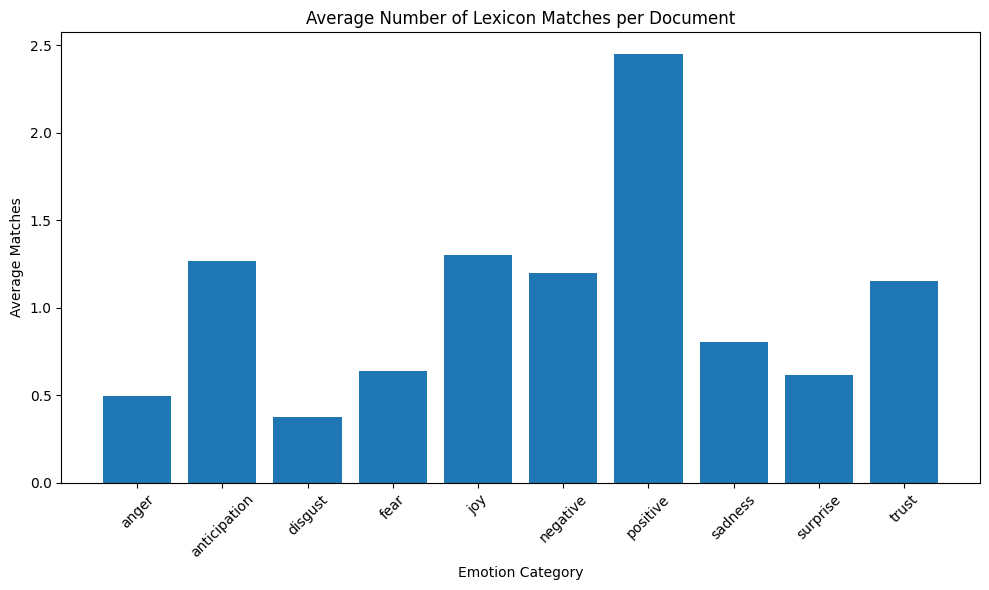

In [16]:
# Load the full NRC Emotion Lexicon
emotion_lexicons = load_nrc_emotion_lexicon()

# Extract lexicon features
X_train_lex = extract_lexicon_features(train_processed, emotion_lexicons)
X_val_lex = extract_lexicon_features(val_processed, emotion_lexicons)
X_test_lex = extract_lexicon_features(test_processed, emotion_lexicons)

print(f"Lexicon features shape: {X_train_lex.shape}")
print(f"Emotions in lexicon: {list(emotion_lexicons.keys())}")

# Calculate average lexicon matches per document
avg_matches = X_train_lex.mean(axis=0)
emotion_names = list(emotion_lexicons.keys())

plt.figure(figsize=(10, 6))
plt.bar(emotion_names, avg_matches)
plt.title('Average Number of Lexicon Matches per Document')
plt.xlabel('Emotion Category')
plt.ylabel('Average Matches')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---

## 4.1 Create Datasets with Different Feature Combinations


In [18]:
# 4.1 Text-only features

# Basic bag-of-words baseline
dataset_bow = {
    'train_X': X_train_bow,
    'val_X': X_val_bow,
    'test_X': X_test_bow,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Bag-of-Words features only'
}

# TF-IDF features
dataset_tfidf = {
    'train_X': X_train_tfidf,
    'val_X': X_val_tfidf,
    'test_X': X_test_tfidf,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'TF-IDF features only'
}

# Word2Vec features
dataset_w2v = {
    'train_X': X_train_w2v,
    'val_X': X_val_w2v,
    'test_X': X_test_w2v,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Word2Vec document embeddings only'
}

# Lexicon features
dataset_lex = {
    'train_X': X_train_lex,
    'val_X': X_val_lex,
    'test_X': X_test_lex,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'NRC Lexicon features only'
}

# 4.2 Categorical features only

# Extract numerical categorical features
cat_features = ['primary_emotion_num', 'secondary_emotions_num', 'interaction_style_num', 'context_num', 'intensity_norm']

X_train_cat = train_df_cat[cat_features].values
X_val_cat = val_df_cat[cat_features].values
X_test_cat = test_df_cat[cat_features].values

dataset_cat = {
    'train_X': X_train_cat,
    'val_X': X_val_cat,
    'test_X': X_test_cat,
    'train_y': train_df_cat['sentiment'],
    'val_y': val_df_cat['sentiment'],
    'test_y': test_df_cat['sentiment'],
    'description': 'Transformed categorical features only'
}

# 4.3 Combined features

# TF-IDF + Lexicon
X_train_tfidf_lex = np.hstack([X_train_tfidf.toarray(), X_train_lex])
X_val_tfidf_lex = np.hstack([X_val_tfidf.toarray(), X_val_lex])
X_test_tfidf_lex = np.hstack([X_test_tfidf.toarray(), X_test_lex])

dataset_tfidf_lex = {
    'train_X': X_train_tfidf_lex,
    'val_X': X_val_tfidf_lex,
    'test_X': X_test_tfidf_lex,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'TF-IDF + NRC Lexicon features'
}

# Word2Vec + Lexicon
X_train_w2v_lex = np.hstack([X_train_w2v, X_train_lex])
X_val_w2v_lex = np.hstack([X_val_w2v, X_val_lex])
X_test_w2v_lex = np.hstack([X_test_w2v, X_test_lex])

dataset_w2v_lex = {
    'train_X': X_train_w2v_lex,
    'val_X': X_val_w2v_lex,
    'test_X': X_test_w2v_lex,
    'train_y': train_df['sentiment'],
    'val_y': val_df['sentiment'],
    'test_y': test_df['sentiment'],
    'description': 'Word2Vec + NRC Lexicon features'
}

# TF-IDF + Categorical
X_train_tfidf_cat = np.hstack([X_train_tfidf.toarray(), X_train_cat])
X_val_tfidf_cat = np.hstack([X_val_tfidf.toarray(), X_val_cat])
X_test_tfidf_cat = np.hstack([X_test_tfidf.toarray(), X_test_cat])

dataset_tfidf_cat = {
    'train_X': X_train_tfidf_cat,
    'val_X': X_val_tfidf_cat,
    'test_X': X_test_tfidf_cat,
    'train_y': train_df_cat['sentiment'],
    'val_y': val_df_cat['sentiment'],
    'test_y': test_df_cat['sentiment'],
    'description': 'TF-IDF + Categorical features'
}

# Word2Vec + Categorical
X_train_w2v_cat = np.hstack([X_train_w2v, X_train_cat])
X_val_w2v_cat = np.hstack([X_val_w2v, X_val_cat])
X_test_w2v_cat = np.hstack([X_test_w2v, X_test_cat])

dataset_w2v_cat = {
    'train_X': X_train_w2v_cat,
    'val_X': X_val_w2v_cat,
    'test_X': X_test_w2v_cat,
    'train_y': train_df_cat['sentiment'],
    'val_y': val_df_cat['sentiment'],
    'test_y': test_df_cat['sentiment'],
    'description': 'Word2Vec + Categorical features'
}

# All features: TF-IDF + Word2Vec + Lexicon + Categorical
X_train_all = np.hstack([X_train_tfidf.toarray(), X_train_w2v, X_train_lex, X_train_cat])
X_val_all = np.hstack([X_val_tfidf.toarray(), X_val_w2v, X_val_lex, X_val_cat])
X_test_all = np.hstack([X_test_tfidf.toarray(), X_test_w2v, X_test_lex, X_test_cat])

dataset_all = {
    'train_X': X_train_all,
    'val_X': X_val_all,
    'test_X': X_test_all,
    'train_y': train_df_cat['sentiment'],
    'val_y': val_df_cat['sentiment'],
    'test_y': test_df_cat['sentiment'],
    'description': 'All features combined'
}

# 4.4 Save all datasets for model evaluation
datasets = {
    'bow': dataset_bow,
    'tfidf': dataset_tfidf,
    'word2vec': dataset_w2v,
    'lexicon': dataset_lex,
    'categorical': dataset_cat,
    'tfidf_lexicon': dataset_tfidf_lex,
    'word2vec_lexicon': dataset_w2v_lex,
    'tfidf_categorical': dataset_tfidf_cat,
    'word2vec_categorical': dataset_w2v_cat,
    'all_features': dataset_all
}

# Print dataset sizes
for name, dataset in datasets.items():
    print(f"{name}: {dataset['train_X'].shape}, {dataset['description']}")

# Save datasets for model training
os.makedirs(project_root / 'data' / 'processed', exist_ok=True)
with open(project_root / 'data' / 'processed' / 'datasets.pkl', 'wb') as f:
    pickle.dump(datasets, f)

bow: (1124, 1447), Bag-of-Words features only
tfidf: (1124, 1447), TF-IDF features only
word2vec: (1124, 100), Word2Vec document embeddings only
lexicon: (1124, 10), NRC Lexicon features only
categorical: (1124, 5), Transformed categorical features only
tfidf_lexicon: (1124, 1457), TF-IDF + NRC Lexicon features
word2vec_lexicon: (1124, 110), Word2Vec + NRC Lexicon features
tfidf_categorical: (1124, 1452), TF-IDF + Categorical features
word2vec_categorical: (1124, 105), Word2Vec + Categorical features
all_features: (1124, 1562), All features combined


## Feature Extraction Summary

We've created a comprehensive set of feature representations for emotion classification, each with different strengths:

1. **Text-based features**:
   - **Bag-of-Words**: Simple frequency-based representation (baseline approach)
   - **TF-IDF**: Enhanced frequency representation that weighs term importance
   - **Word2Vec**: Dense semantic representation capturing word relationships
   - **NRC Emotion Lexicon**: Domain-specific features based on an emotion dictionary

2. **Categorical features**:
   - Transformed categorical columns into numerical values based on their probabilistic relationship with sentiment

3. **Combined representations**:
   - Various combinations of text and categorical features to leverage different aspects of the data

These different feature sets will allow us to evaluate which types of information are most valuable for emotion classification. In the next notebook, we'll train and evaluate models using each of these feature sets to determine the optimal approach.